author: Daniel Dachs

date: 17/02/2026

version: 1

We are identifying genomes which contain our protein domain BLUF (as reported in InterPro) in the Burkholderiales order as set out in the Phylogenetic tree provided by GTDB. Here we will report the genomes and taxanomic structure of our selection.

Most of the work for this analysis was already completed in the scripts  [gtdb_access.py](src/gtdb_access.py) and [gtdb_taxonomy_analysis.py](src/gtdb_taxonomy_analysis.py)

In [ ]:
from src.DarwinsRNAHunt.gtdb_access import download_and_load_bacteria_tree, download_and_load_bacteria_metadata, get_ncbi_to_gtdb_dict, save_tree_ete3, save_metadata
from src.DarwinsRNAHunt.gtdb_taxonomy_analysis import trim_tree_to_taxa
from src.DarwinsRNAHunt.interpro_access import download_and_save_taxanomic_info, get_taxa_ids

from Bio import Phylo

Now we want to download the gtdb bacterial taxonomic tree and associated meta data

In [2]:
gtdb_bacteria_tree = download_and_load_bacteria_tree()
gtdb_bacteria_metadata = download_and_load_bacteria_metadata()

Downloading: https://data.gtdb.ecogenomic.org/releases/latest/bac120.tree
Saved: data/taxa_trees/bac120.tree
Downloading: https://data.gtdb.ecogenomic.org/releases/latest/bac120_metadata.tsv.gz
Saved: data/taxa_trees/bac120_metadata.tsv.gz


and the BLUF taxanomic information from interpro (IPR007024 is the BLUF interpro ID)

In [3]:
bluf_taxonomy = download_and_save_taxanomic_info("IPR007024")
bluf_ncbi_taxids = get_taxa_ids(bluf_taxonomy)

Now we have to translate from the NCBI accession ids to the GTDB accessions - this mapping is containd in the GTDB meta data we just downloaded. Note this also excludes non bacterial genomes from interpro.

In [4]:
taxa_dict = get_ncbi_to_gtdb_dict()

bluf_gtdb_taxaids = set()
no_mapping_count = 0

for ncbi_id in bluf_ncbi_taxids:
    if ncbi_id in taxa_dict.keys():
        bluf_gtdb_taxaids.update(taxa_dict[ncbi_id])
    else:
        no_mapping_count += 1

print(f"NCBI taxonomy IDs which do not map to GTDB accessions: {no_mapping_count} of a total {len(bluf_ncbi_taxids)}")

NCBI taxonomy IDs which do not map to GTDB accessions: 466 of a total 3790


Now we want to trim down our tree just to the BLUF containing species from our tree, save this while we're at it. Note the tree contains representative genome accessions so we are expecting not to map all our taxa to the tree.

In [5]:
bluf_tree = trim_tree_to_taxa(gtdb_bacteria_tree, bluf_gtdb_taxaids)
save_tree_ete3(bluf_tree, "BLUF_bacGTDBtaxanomy.tree")

Trimming tree to 106876 taxa...
  Taxa in tree: 3800/106876
  First 10 missing taxa:
    - RS_GCF_022236605.1
    - GB_GCA_032090655.1
    - RS_GCF_902703135.1
    - RS_GCF_029783065.1
    - RS_GCF_002233385.1
    - GB_GCA_901420495.1
    - RS_GCF_902505175.1
    - GB_GCA_019802385.1
    - RS_GCF_030375065.1
    - RS_GCF_013370735.1
Trimmed tree has 3800 leaves


'data/taxa_trees/BLUF_bacGTDBtaxanomy.tree'

Now we have a taxanomic tree of bacterial species containg our BLUF domian gene. We can now extract a subtree for clade Burkholderiales.

There are 508 accessions in this subtree


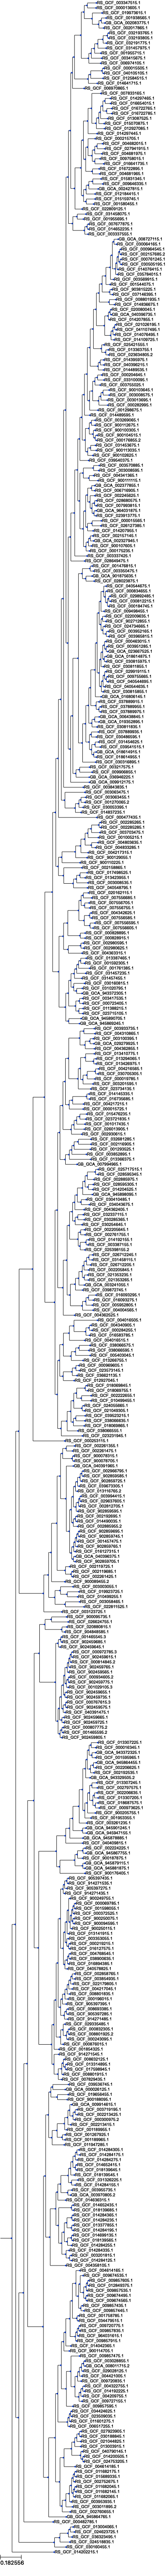

In [6]:
order_of_interest = "36.0:f__Burkholderiaceae"

burkholderiales_bluf_tree = None

for node in bluf_tree.traverse():
    if node.name == order_of_interest:
        burkholderiales_bluf_tree = node
        break

selected_accession_names = burkholderiales_bluf_tree.get_leaf_names()

print("There are %d accessions in this subtree" % len(selected_accession_names))

select_accessions = gtdb_bacteria_metadata[gtdb_bacteria_metadata["accession"].isin(selected_accession_names)]

select_accessions.to_csv("data/bluf_accessions_of_interest.csv", index = False)

burkholderiales_bluf_tree.render("%%inline")

The above tree is a subtree of the GTDB representative phylogenetic tree of the Burkholderiaceae family where BLUF is found. GTDB provides metadata for these accessions, including CheckM2 completeness and contamination measures. For our future analysis we want high quality reads, so its worth filtering by completeness and contamination (https://pmc.ncbi.nlm.nih.gov/articles/PMC10963913/#:~:text=We%20recommend%20the%20use%20of,for%20its%20use%20in%20taxonomy, https://www.nature.com/articles/s41592-023-01940-w#:~:text=To%20assess%20performance%20of%20ML,were%20used%20in%20subsequent%20testing.generally) generally considered high quality if completeness >90%, contamination <5% We can afford to be a little more picky.

In [10]:
completeness_threshold = 99.9
contamination_threshold = 1

high_quality_select_accessions= select_accessions[(select_accessions["checkm2_completeness"]>completeness_threshold) & (select_accessions["checkm2_contamination"]<contamination_threshold)]

save_metadata(high_quality_select_accessions, "hq_bluf_accessions_of_interest.tsv.gz")

# also save accession ids to txt file
high_quality_select_accessions['accession'].to_csv('data/highqualtyaccessions.txt', index=False, header=False)

print(f"Accessions determined to be high quality (completeness >{completeness_threshold}%, contamination <{contamination_threshold}%): {len(high_quality_select_accessions)} of a total {len(select_accessions)}")

Accessions determined to be high quality (completeness >99.9%, contamination <1%): 339 of a total 508


Just want to check if we are hugely biasing taxanomic distrbution doing this, will do a quick check by highlighting our select accessins on our phylogenetic tree.

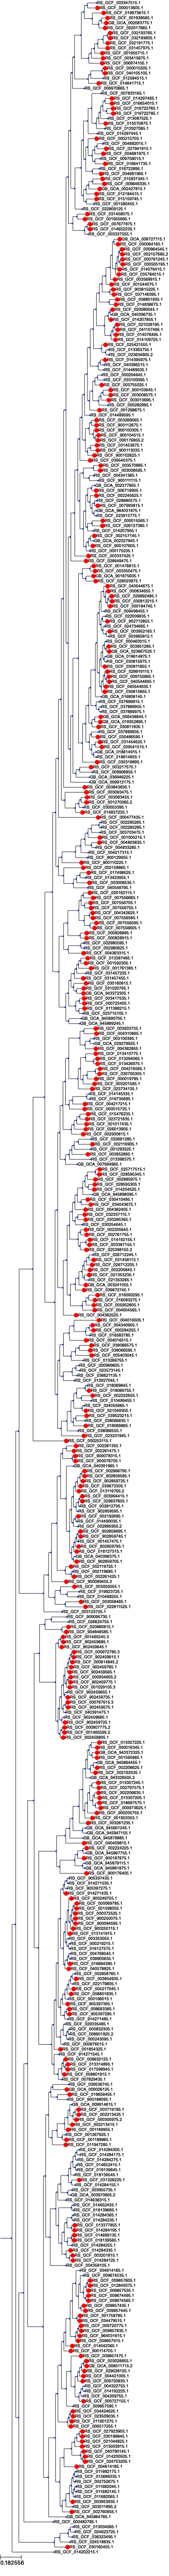

In [8]:
from ete3 import NodeStyle, TextFace

nstyle = NodeStyle()
nstyle["fgcolor"] = "red"
nstyle["size"] = 10

for n in burkholderiales_bluf_tree.traverse():
    if n.name in high_quality_select_accessions["accession"].values:
        n.set_style(nstyle)

burkholderiales_bluf_tree.render("%%inline")